In [6]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 615 (delta 13), reused 20 (delta 10), pack-reused 586 (from 1)
Receiving objects: 100% (615/615), 764.37 KiB | 26.36 MiB/s, done.
Resolving deltas: 100% (291/291), done.
/content/NuOscProbExact


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from NuOscProbExact.src.oscprob3nu import probabilities_3nu

# Constants and parameters
theta12 = np.radians(33.36)
theta23 = np.radians(45)
theta13 = np.radians(8.46)
delta_cp = np.radians(0)
mass_squared_difference21 = 7.53e-5
mass_squared_difference31 = 2.44e-3
Length = 500

# Define the Hamiltonian matrix
hamiltonian = [
    [1.0+0.0j, 0.0+2.0j, 0.0-1.0j],
    [0.0-2.0j, 3.0+0.0j, 3.0+0.0j],
    [0.0+1.0j, 3.0-0.0j, 5.0+0.0j]
]

# Calculate probabilities
Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(hamiltonian, Length)

# Print probabilities
print("Pee = %6.5f, Pem = %6.5f, Pet = %6.5f" % (Pee, Pem, Pet))
print("Pme = %6.5f, Pmm = %6.5f, Pmt = %6.5f" % (Pme, Pmm, Pmt))
print("Pte = %6.5f, Ptm = %6.5f, Ptt = %6.5f" % (Pte, Ptm, Ptt))



Pee = 0.66360, Pem = 0.18137, Pet = 0.15503
Pme = 0.18137, Pmm = 0.63251, Pmt = 0.18612
Pte = 0.15503, Ptm = 0.18612, Ptt = 0.65886


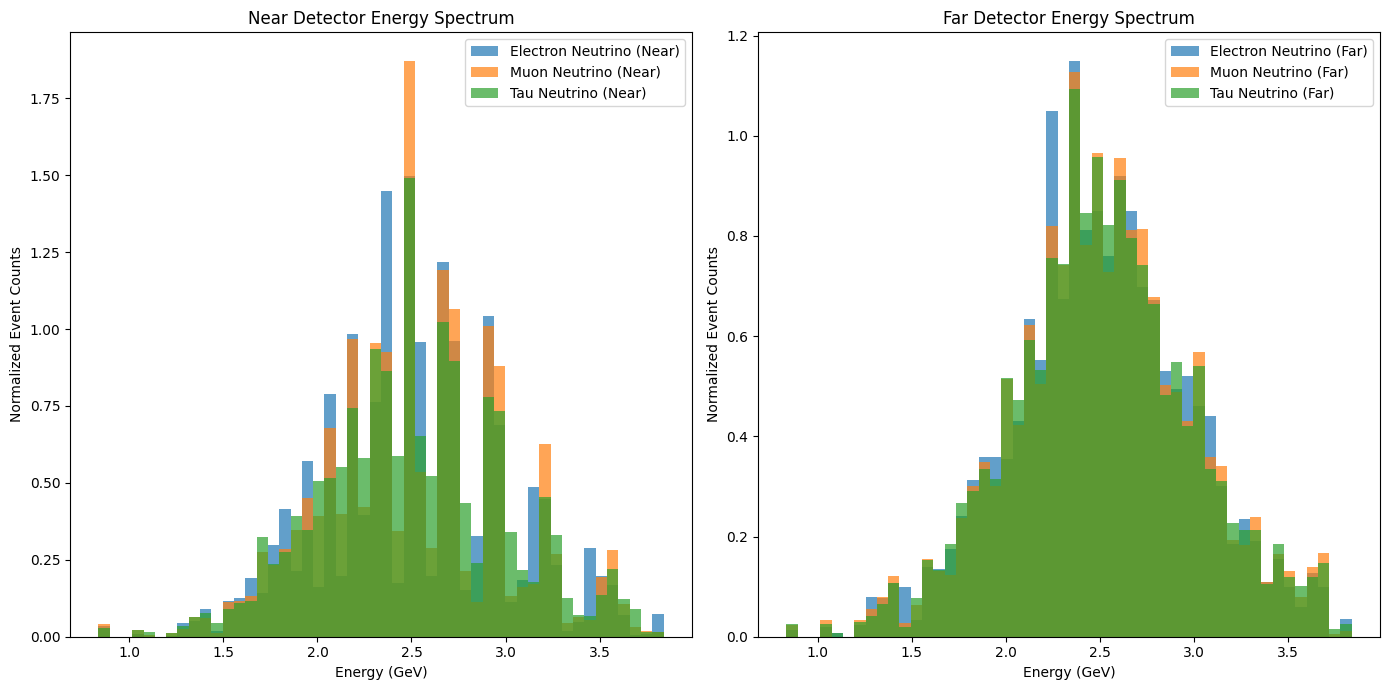

In [16]:
# Import libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from src.oscprob3nu import probabilities_3nu

#parameters
theta12 = np.radians(33.41)
theta23 = np.radians(49.1)
theta13 = np.radians(8.54)
delta_cp = np.radians(197)
mass_squared_difference21 = 7.53e-5
mass_squared_difference31 = 2.4e-3
Length_near = 50  # Near detector distance in km
Length_far = 1300  # Far detector distance in km

# Define the Hamiltonian (simplified for example)
hamiltonian = lambda L: [
    [1.0/L + 0.0j, 0.0 + 2.0j / L, 0.0 - 1.0j / L],
    [0.0 - 2.0j / L, 3.0 / L + 0.0j, 3.0 / L + 0.0j],
    [0.0 + 1.0j / L, 3.0 / L - 0.0j, 5.0 / L + 0.0j]
]

#Gaussian distribution parameters
mean_energy = 2.5  # Mean energy
sigma_energy = 0.5  # Standard deviation
energies = np.random.normal(mean_energy, sigma_energy, 1000)

# Function to compute probabilities for a given length
def compute_probabilities(length):
    Prob_e = []
    Prob_mu = []
    Prob_tau = []

    for E in energies:
        H = hamiltonian(E)
        Pee, Pem, Pet, Pme, Pmm, Pmt, Pte, Ptm, Ptt = probabilities_3nu(H, length)
        Prob_e.append(Pee)
        Prob_mu.append(Pmm)
        Prob_tau.append(Ptt)

    return np.array(Prob_e), np.array(Prob_mu), np.array(Prob_tau)

# Compute probabilities for near and far detectors
Prob_e_near, Prob_mu_near, Prob_tau_near = compute_probabilities(Length_near)
Prob_e_far, Prob_mu_far, Prob_tau_far = compute_probabilities(Length_far)

# Total number of events
total_events = 1000

# Poisson-distributed event counts based on the probability
counts_e_near = np.random.poisson(lam=Prob_e_near * total_events)
counts_mu_near = np.random.poisson(lam=Prob_mu_near * total_events)
counts_tau_near = np.random.poisson(lam=Prob_tau_near * total_events)

counts_e_far = np.random.poisson(lam=Prob_e_far * total_events)
counts_mu_far = np.random.poisson(lam=Prob_mu_far * total_events)
counts_tau_far = np.random.poisson(lam=Prob_tau_far * total_events)

# Plot the histograms
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies, bins=50, weights=counts_e_near, label='Electron Neutrino (Near)', alpha=0.7, density=True)
plt.hist(energies, bins=50, weights=counts_mu_near, label='Muon Neutrino (Near)', alpha=0.7, density=True)
plt.hist(energies, bins=50, weights=counts_tau_near, label='Tau Neutrino (Near)', alpha=0.7, density=True)
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies, bins=50, weights=counts_e_far, label='Electron Neutrino (Far)', alpha=0.7, density=True)
plt.hist(energies, bins=50, weights=counts_mu_far, label='Muon Neutrino (Far)', alpha=0.7, density=True)
plt.hist(energies, bins=50, weights=counts_tau_far, label='Tau Neutrino (Far)', alpha=0.7, density=True)
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()

plt.tight_layout()
plt.show()


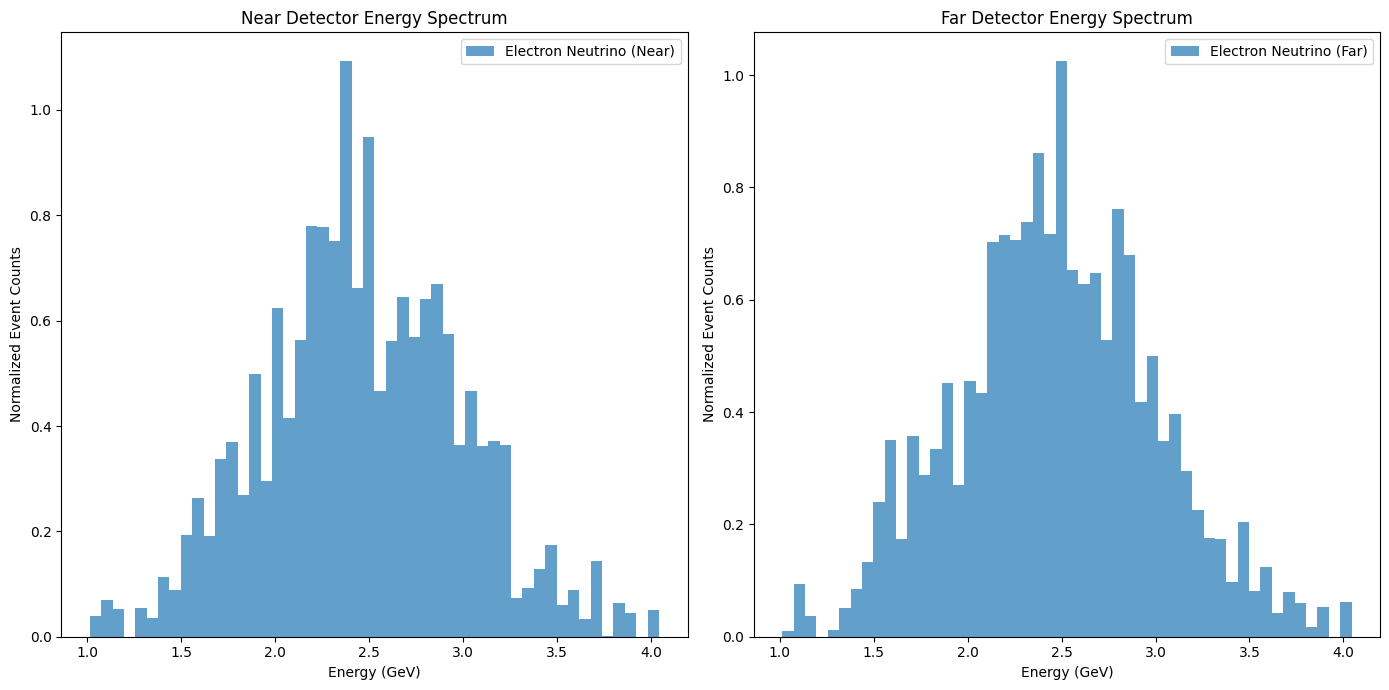

In [14]:
# Plot the histograms
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies, bins=50, weights=counts_e_near, label='Electron Neutrino (Near)', alpha=0.7, density=True)

plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Near Detector Energy Spectrum')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies, bins=50, weights=counts_e_far, label='Electron Neutrino (Far)', alpha=0.7, density=True)
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Far Detector Energy Spectrum')
plt.legend()

plt.tight_layout()
plt.show()


Focus on Electron Neutrino




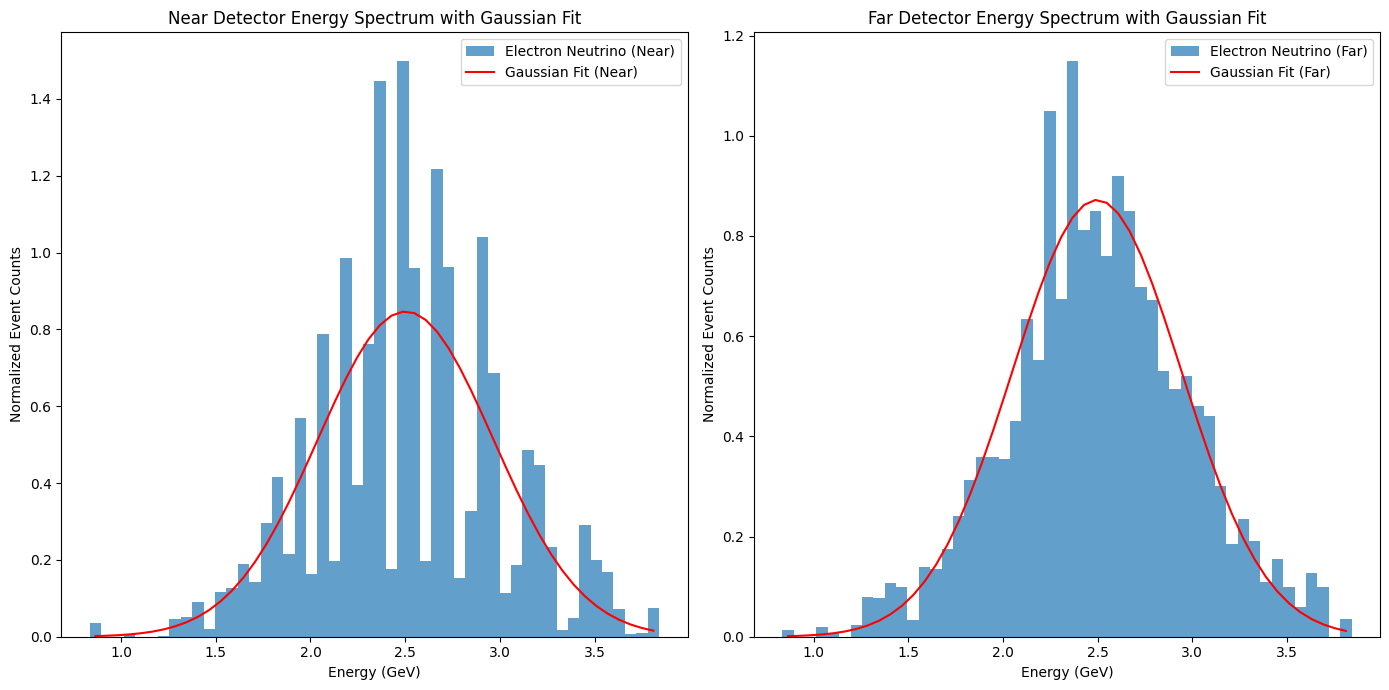

Near detector Gaussian parameters: amplitude = 0.85, mean = 2.50, sigma = 0.46
Far detector Gaussian parameters: amplitude = 0.87, mean = 2.50, sigma = 0.45


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Generate histogram data for fitting
bin_centers_near = (np.histogram(energies, bins=50)[1][:-1] + np.histogram(energies, bins=50)[1][1:]) / 2
bin_centers_far = bin_centers_near.copy()

# Compute the histogram for electron neutrinos (near and far detectors)
hist_e_near, _ = np.histogram(energies, bins=50, weights=counts_e_near, density=True)
hist_e_far, _ = np.histogram(energies, bins=50, weights=counts_e_far, density=True)

# Initial guesses for Gaussian parameters [amplitude, mean, sigma]
initial_guess = [1, mean_energy, sigma_energy]

# Fit Gaussian to the near detector data
params_near, _ = curve_fit(gaussian, bin_centers_near, hist_e_near, p0=initial_guess)
fit_near = gaussian(bin_centers_near, *params_near)

# Fit Gaussian to the far detector data
params_far, _ = curve_fit(gaussian, bin_centers_far, hist_e_far, p0=initial_guess)
fit_far = gaussian(bin_centers_far, *params_far)

# Plot the histograms and the fitted curves
plt.figure(figsize=(14, 7))

# Near detector
plt.subplot(1, 2, 1)
plt.hist(energies, bins=50, weights=counts_e_near, label='Electron Neutrino (Near)', alpha=0.7, density=True)
plt.plot(bin_centers_near, fit_near, label='Gaussian Fit (Near)', color='r')
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Near Detector Energy Spectrum with Gaussian Fit')
plt.legend()

# Far detector
plt.subplot(1, 2, 2)
plt.hist(energies, bins=50, weights=counts_e_far, label='Electron Neutrino (Far)', alpha=0.7, density=True)
plt.plot(bin_centers_far, fit_far, label='Gaussian Fit (Far)', color='r')
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Far Detector Energy Spectrum with Gaussian Fit')
plt.legend()

plt.tight_layout()
plt.show()

# Print the fit parameters
print(f"Near detector Gaussian parameters: amplitude = {params_near[0]:.2f}, mean = {params_near[1]:.2f}, sigma = {params_near[2]:.2f}")
print(f"Far detector Gaussian parameters: amplitude = {params_far[0]:.2f}, mean = {params_far[1]:.2f}, sigma = {params_far[2]:.2f}")


Overlap Gaussian Curves for Each Detector

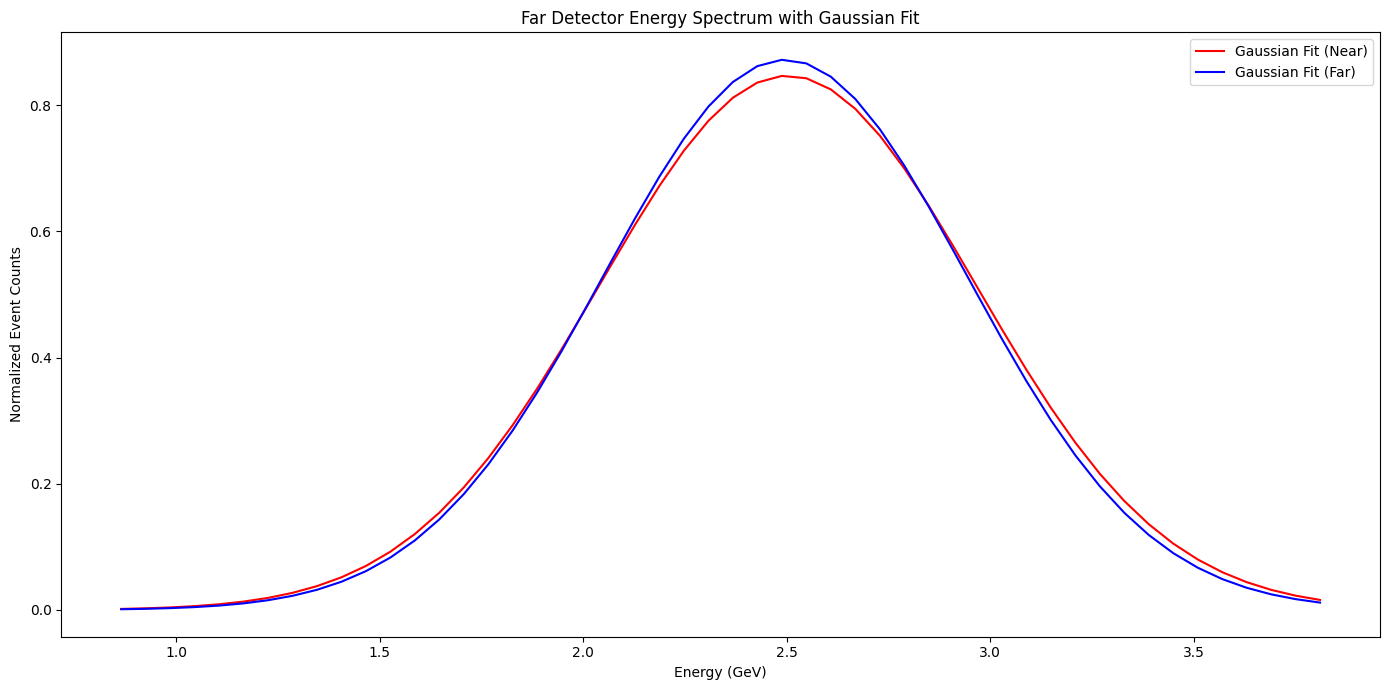

In [19]:
# Plot the histograms and the fitted curves
plt.figure(figsize=(14, 7))
plt.plot(bin_centers_near, fit_near, label='Gaussian Fit (Near)', color='r')
plt.plot(bin_centers_far, fit_far, label='Gaussian Fit (Far)', color='b')
plt.xlabel('Energy (GeV)')
plt.ylabel('Normalized Event Counts')
plt.title('Far Detector Energy Spectrum with Gaussian Fit')
plt.legend()

plt.tight_layout()
plt.show()